# Random imputation

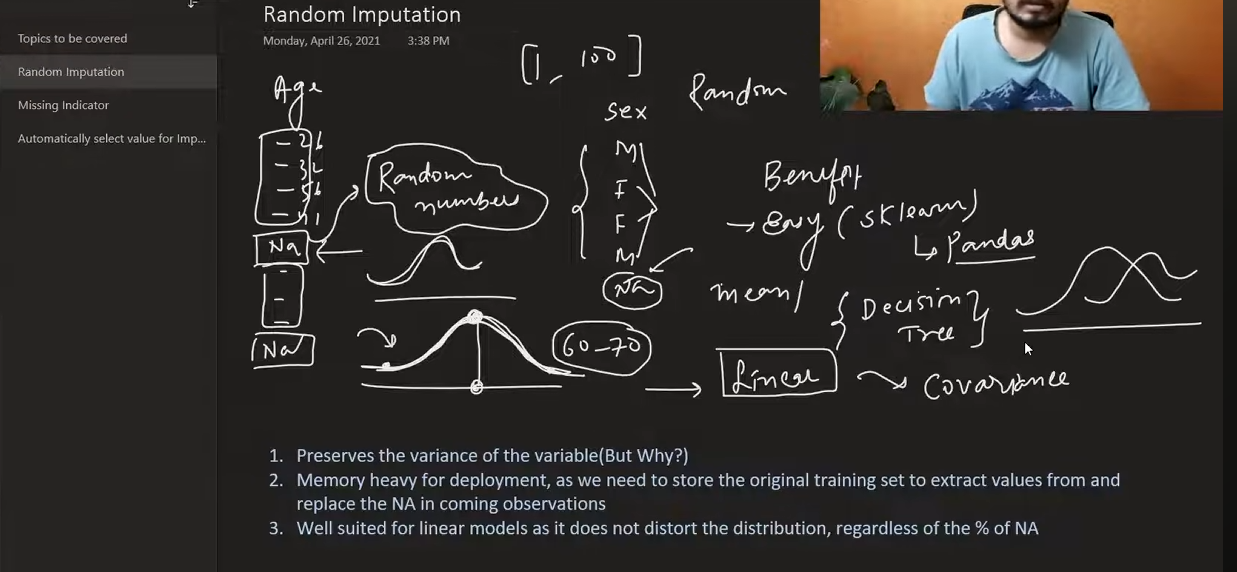



* we take random values from the present data
* it is used in both numerical and categorical
* data distribution will be almost same
* it works good on linear based algorithms
* we use random technique more while using linear algorithm on our data
* it doesn't work good on decision tree
* covariance gets disturbed

In [37]:
# Dataset is bit different so getting different results than sir

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import  train_test_split

In [3]:
df = pd.read_csv('modifiedTitanic.csv',usecols = ['Age', 'Fare','Survived'])

In [4]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [5]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [6]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state= 2)

In [8]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed'] = x_test['Age']

In [9]:


x_train

,Age,Fare,age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [10]:
x_train.loc[x_train['age_imputed'].isnull(), 'age_imputed'] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

x_test.loc[x_test['age_imputed'].isnull(), 'age_imputed'] = x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [11]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([18.  ,  2.  , 19.  , 34.  ,  2.  , 35.  , 43.  , 29.  , 18.  ,
       23.  ,  4.  , 33.  , 30.  , 51.  , 46.  , 48.  ,  4.  , 42.  ,
       20.  ,  4.  , 39.  , 31.  , 25.  , 21.  ,  9.  , 24.  , 22.  ,
       26.  , 36.  , 50.  ,  2.  , 28.  ,  9.  , 29.  ,  7.  , 36.  ,
       20.  , 36.  , 36.  , 35.  , 24.  , 27.  , 17.  , 47.  , 58.  ,
       16.  , 42.  , 30.  , 36.  , 62.  , 36.  ,  2.  , 32.  , 34.  ,
       41.  , 66.  , 61.  , 20.  , 30.  , 13.  ,  5.  ,  4.  , 24.  ,
       19.  , 47.  , 23.  , 60.  , 20.  , 20.  , 36.  , 36.  , 23.  ,
       25.  , 19.  , 14.  , 29.  ,  0.75, 18.  , 22.  , 24.  , 29.  ,
       16.  , 16.  , 19.  , 29.  ,  3.  , 24.  , 54.  ,  8.  , 23.  ,
       31.  , 26.  , 15.  , 35.  ,  9.  , 28.  , 45.  , 14.  , 64.  ,
       25.  , 41.  , 30.  , 32.  , 45.  , 60.  , 24.  , 18.  , 32.  ,
       23.  , 24.  , 32.  , 25.  , 40.  , 16.  , 27.  , 38.  , 57.  ,
       17.  , 18.  , 34.  , 25.  , 49.  , 39.  , 21.  , 30.  , 24.  ,
       37.  , 52.  ,

In [12]:
x_train['Age'].isnull().sum()

np.int64(148)

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\3190353041.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label = 'original',hist=False)
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\3190353041.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5

<Axes: xlabel='age_imputed', ylabel='Density'>

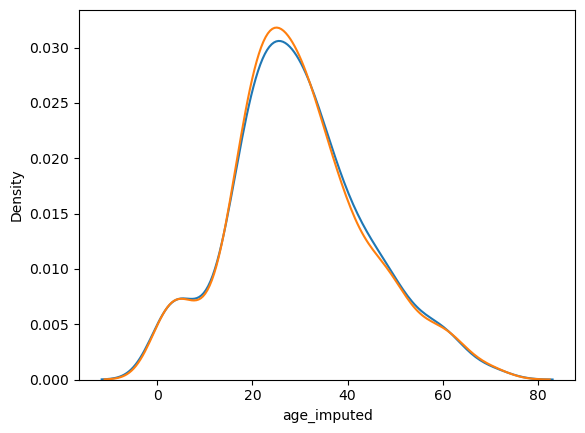

In [13]:
sns.distplot(x_train['Age'],label = 'original',hist=False)
sns.distplot(x_train['age_imputed'],label = 'imputed',hist = False)

In [14]:
print('original varialbe variance:', x_train['Age'].var())
print('variance after random imputation :', x_train['age_imputed'].var())


original varialbe variance: 204.3495133904614
variance after random imputation : 202.45689234896273


In [15]:
x_train[['Fare','Age','age_imputed']].cov()

,Fare,Age,age_imputed
Fare,2448.197914,70.719262,71.757272
Age,70.719262,204.349513,204.349513
age_imputed,71.757272,204.349513,202.456892


<Axes: >

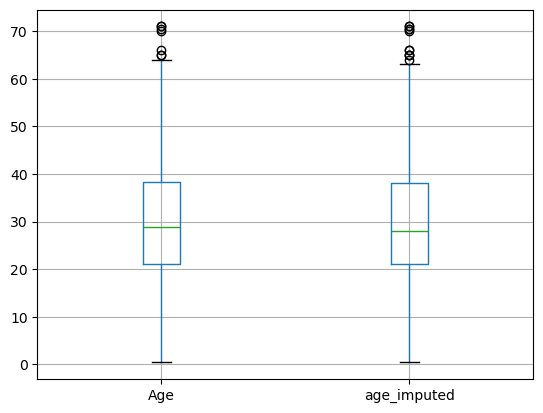

In [16]:
x_train[['Age','age_imputed']].boxplot()

In [17]:
observation = x_train.iloc[0]
sampled_value = x_train['Age'].dropna().sample(1,random_state= int(observation['Fare']))

In [18]:
df = pd.read_csv('trainModified.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [19]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [20]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [21]:
x = df
y = df['SalePrice']

In [22]:
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size= 2, random_state = 2)

In [23]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']


x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [24]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
583,Gd,Gd,325000,Gd,Gd
323,NaN,Fa,126175,Fa,NaN
123,NaN,TA,153900,TA,NaN
1400,Gd,TA,120000,TA,Gd
979,NaN,TA,139000,TA,NaN


In [25]:
x_train.loc[x_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test.loc[x_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values


x_train.loc[x_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test.loc[x_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values 

In [26]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts()/len(x_train)
    ],
    axis = 1)

temp.columns = ['original','imputed']

In [27]:
temp

,original,imputed
TA,0.950617,0.951303
Fa,0.034858,0.034294
Gd,0.010167,0.010288
Ex,0.002179,0.002058
Po,0.002179,0.002058


In [28]:
temp = pd.concat(
    [
        x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts()/len(x_train)
    ],
    axis = 1)

temp.columns = ['original','imputed']

In [29]:
temp

,original,imputed
Gd,0.494792,0.500000
TA,0.404948,0.397805
Fa,0.042969,0.043896
Ex,0.031250,0.031550
Po,0.026042,0.026749


C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\1940062574.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\1940062574.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com

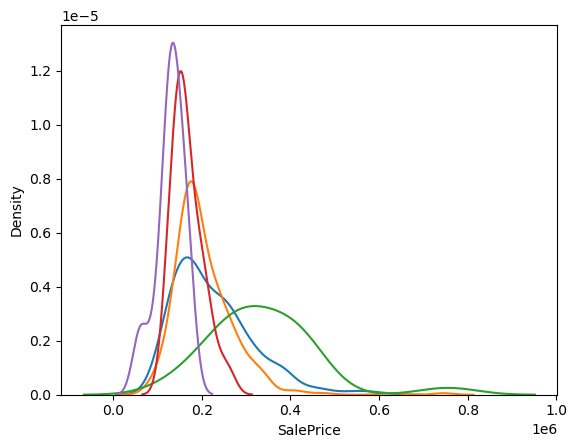

In [35]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
    
plt.show()    

C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\984094484.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Abhinav Harivanshi\AppData\Local\Temp\ipykernel_18660\984094484.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.gith

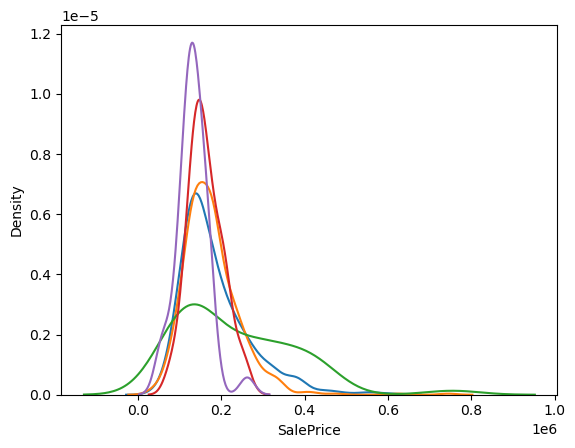

In [36]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
    
plt.show()    

# Missing indicator
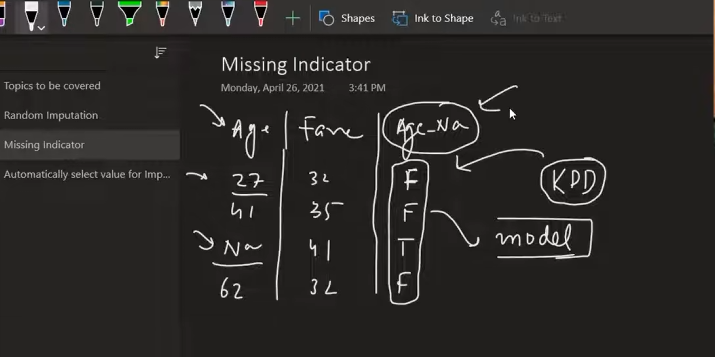

If there is missing value in any column we create a new column and whereever is the missing value 
get True else False

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

In [113]:
df = pd.read_csv('modifiedTitanic.csv',usecols = ['Survived','Age','Fare'])

In [114]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [115]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [116]:
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [117]:
x_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [118]:
si = SimpleImputer()
x_train_trf = si.fit_transform(x_train)
x_test_trf = si.transform(x_test)

In [119]:
x_train_trf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]], shape=(712, 2))

In [120]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train_trf,y_train)

y_pred = clf.predict(x_test_trf)
accuracy_score(y_test,y_pred)


0.6033519553072626

In [121]:
mi = MissingIndicator()
mi.fit(x_train)

,missing_values,nan
,features,'missing-only'
,sparse,'auto'
,error_on_new,True


In [122]:
mi.features_

array([0, 1])

In [123]:
x_train_missing = mi.transform(x_train)

In [124]:
x_train_missing

array([[False, False],
       [False, False],
       [False, False],
       ...,
       [False, False],
       [ True, False],
       [ True, False]], shape=(712, 2))

In [125]:
x_test_missing = mi.transform(x_test)

In [126]:
x_test_missing

array([[False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [ True, False],
       [False, False],
       [ True, False],
       [False, False],
       [False,  True],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False,  True],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False,  True],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [Fal

In [129]:
x_train['age_na'] = x_train_missing[:, 0]

In [130]:
x_test['age_na'] = x_test_missing[:, 0]

In [131]:
x_train

,Age,Fare,age_na
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [137]:
si = SimpleImputer()

x_train_trf2 = si.fit_transform(x_train)
x_test_trf2 = si.transform(x_test)

In [139]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(x_train_trf2,y_train)

y_pred = clf.predict(x_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6201117318435754

# we can use directly indicator class without doing manually

In [140]:
si = SimpleImputer(add_indicator = True)

In [141]:
x_train = si.fit_transform(x_train)

In [142]:
x_test = si.transform(x_test)

In [143]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(x_train_trf2, y_train)

y_pred = clf.predict(x_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6201117318435754

# Automatically select value for imputation
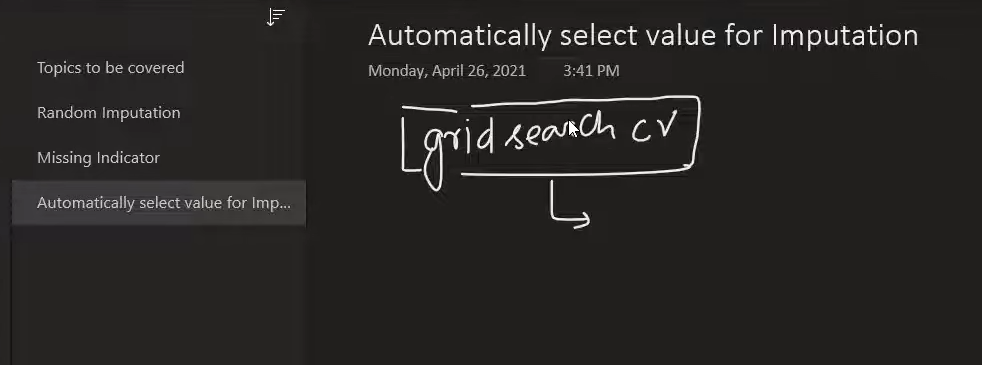

scikitLearn try all posible combination to get bestresult

In [187]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [188]:
df = pd.read_csv('titanic.csv')

In [189]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [190]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

In [191]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [192]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [193]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state= 2)

In [194]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [201]:
numerical_feature = ['Age','Fare']

numerical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked','Sex']
categorical_transformer = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown = 'ignore'))
])

In [202]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer,numerical_feature),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [203]:
clf = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier', LogisticRegression())
])

In [204]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

In [205]:
grid_search.fit(x_train,y_train)

print(f"best params")
print(grid_search.best_params_)

best params
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [206]:
print(f'Internal CV score: {grid_search.best_score_:.3f}')

Internal CV score: 0.788


In [207]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)
cv_results[['param_classifier__C', 'param_preprocessor__cat__imputer__strategy', 'param_preprocessor__num__imputer__strategy', 'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
4,1.0,most_frequent,mean,0.787852
5,1.0,most_frequent,median,0.787852
6,1.0,constant,mean,0.787852
7,1.0,constant,median,0.787852
8,10.0,most_frequent,mean,0.787852
9,10.0,most_frequent,median,0.787852
10,10.0,constant,mean,0.787852
11,10.0,constant,median,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852
